# Unified Checkpointing Design Diagrams

This notebook generates all architecture diagrams for the Unified Checkpointing Design document.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle, Polygon
import matplotlib.lines as mlines
import numpy as np

# Enable inline display
%matplotlib inline

In [2]:
# Common colors
COLORS = {
    'app': '#E3F2FD',      # Light blue
    'manager': '#FFF3E0',   # Light orange
    'trait': '#E8F5E9',     # Light green
    'impl': '#FCE4EC',      # Light pink
    'shared': '#F3E5F5',    # Light purple
    'storage': '#E0F7FA',   # Light cyan
    'coord': '#FFF8E1',     # Light amber
    'border': '#333333',
    'arrow': '#333333',
    'text': '#333333',
    'highlight': '#FF5722', # Deep orange for highlights
    'safe': '#4CAF50',      # Green for safe points
    'danger': '#F44336',    # Red for danger
    'warning': '#FFC107',   # Amber for warnings
}

In [3]:
def setup_ax(fig, ax, title=None):
    """Common axis setup."""
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)


def draw_box(ax, x, y, width, height, label, sublabel=None, color='white', fontsize=10, text_color='#333333'):
    """Draw a rounded box with text."""
    box = FancyBboxPatch((x, y), width, height,
                         boxstyle="round,pad=0.02,rounding_size=0.1",
                         facecolor=color, edgecolor=COLORS['border'], linewidth=1.5)
    ax.add_patch(box)

    if sublabel:
        ax.text(x + width/2, y + height/2 + 0.15, label,
               ha='center', va='center', fontsize=fontsize, fontweight='bold', color=text_color)
        ax.text(x + width/2, y + height/2 - 0.2, sublabel,
               ha='center', va='center', fontsize=fontsize-2, style='italic', color=text_color)
    else:
        ax.text(x + width/2, y + height/2, label,
               ha='center', va='center', fontsize=fontsize, fontweight='bold', color=text_color)


def draw_arrow(ax, x1, y1, x2, y2, color=None, style='->', linewidth=1.5):
    """Draw an arrow."""
    if color is None:
        color = COLORS['arrow']
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
               arrowprops=dict(arrowstyle=style, color=color, lw=linewidth))

## Diagram 1: 2PC Protocol Flow

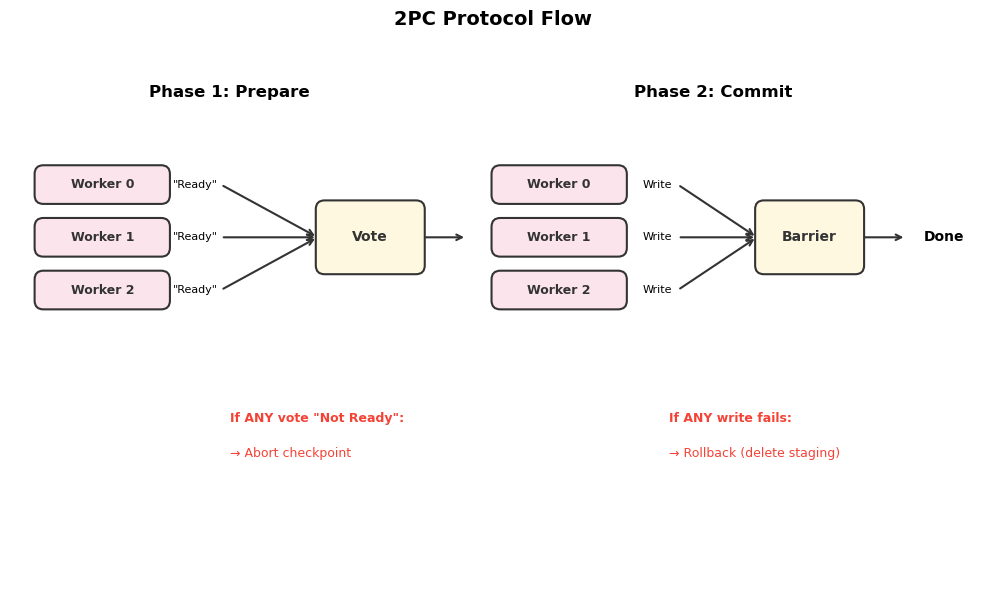

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
setup_ax(fig, ax, '2PC Protocol Flow')

# Phase 1: Prepare
ax.text(2.5, 5.5, 'Phase 1: Prepare', fontsize=12, fontweight='bold', ha='center')

# Workers voting
for i, label in enumerate(['Worker 0', 'Worker 1', 'Worker 2']):
    y = 4.5 - i * 0.6
    draw_box(ax, 0.3, y - 0.2, 1.5, 0.4, label, color=COLORS['impl'], fontsize=9)
    ax.text(1.85, y, '"Ready"', fontsize=8, va='center', ha='left')
    draw_arrow(ax, 2.4, y, 3.5, 3.9)

# Vote aggregation
draw_box(ax, 3.5, 3.5, 1.2, 0.8, 'Vote', color=COLORS['coord'], fontsize=10)
draw_arrow(ax, 4.7, 3.9, 5.2, 3.9)

# Phase 2: Commit
ax.text(8, 5.5, 'Phase 2: Commit', fontsize=12, fontweight='bold', ha='center')

# Workers writing
for i, label in enumerate(['Worker 0', 'Worker 1', 'Worker 2']):
    y = 4.5 - i * 0.6
    draw_box(ax, 5.5, y - 0.2, 1.5, 0.4, label, color=COLORS['impl'], fontsize=9)
    ax.text(7.2, y, 'Write', fontsize=8, va='center')
    draw_arrow(ax, 7.6, y, 8.5, 3.9)

# Barrier
draw_box(ax, 8.5, 3.5, 1.2, 0.8, 'Barrier', color=COLORS['coord'], fontsize=10)
draw_arrow(ax, 9.7, 3.9, 10.2, 3.9)
ax.text(10.4, 3.9, 'Done', fontsize=10, fontweight='bold', va='center')

# Failure paths
ax.text(2.5, 1.8, 'If ANY vote "Not Ready":', fontsize=9, fontweight='bold', color=COLORS['danger'])
ax.text(2.5, 1.4, '→ Abort checkpoint', fontsize=9, color=COLORS['danger'])

ax.text(7.5, 1.8, 'If ANY write fails:', fontsize=9, fontweight='bold', color=COLORS['danger'])
ax.text(7.5, 1.4, '→ Rollback (delete staging)', fontsize=9, color=COLORS['danger'])

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/2pc_protocol.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 2: Checkpoint Decision Flow

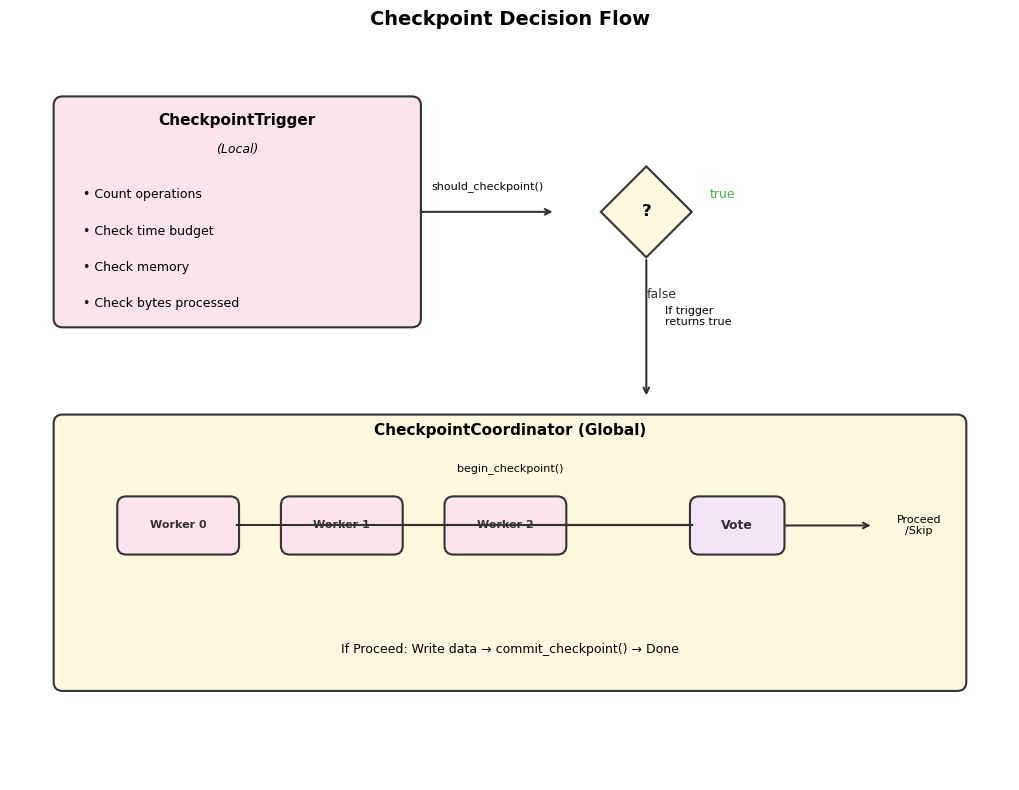

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
setup_ax(fig, ax, 'Checkpoint Decision Flow')

# Local Trigger box
draw_box(ax, 0.5, 5, 4, 2.5, '', color=COLORS['impl'])
ax.text(2.5, 7.2, 'CheckpointTrigger', fontsize=11, fontweight='bold', ha='center')
ax.text(2.5, 6.9, '(Local)', fontsize=9, ha='center', style='italic')
ax.text(0.8, 6.4, '• Count operations', fontsize=9)
ax.text(0.8, 6.0, '• Check time budget', fontsize=9)
ax.text(0.8, 5.6, '• Check memory', fontsize=9)
ax.text(0.8, 5.2, '• Check bytes processed', fontsize=9)

# Arrow to decision
draw_arrow(ax, 4.5, 6.25, 6, 6.25)
ax.text(5.25, 6.5, 'should_checkpoint()', fontsize=8, ha='center')

# Decision diamond (simulated with rotated square)
diamond = plt.Polygon([[6.5, 6.25], [7, 6.75], [7.5, 6.25], [7, 5.75]],
                      facecolor=COLORS['coord'], edgecolor=COLORS['border'], linewidth=1.5)
ax.add_patch(diamond)
ax.text(7, 6.25, '?', fontsize=12, ha='center', va='center', fontweight='bold')

# True/False paths
ax.text(7.7, 6.4, 'true', fontsize=9, color=COLORS['safe'])
ax.text(7, 5.3, 'false', fontsize=9, color=COLORS['text'])

# Arrow from diamond down to coordinator
draw_arrow(ax, 7, 5.75, 7, 4.2)
ax.text(7.2, 5, 'If trigger\nreturns true', fontsize=8)

# Global Coordinator box
draw_box(ax, 0.5, 1, 10, 3, '', color=COLORS['coord'])
ax.text(5.5, 3.8, 'CheckpointCoordinator (Global)', fontsize=11, fontweight='bold', ha='center')

# begin_checkpoint() label at top
ax.text(5.5, 3.4, 'begin_checkpoint()', fontsize=8, ha='center')

# Workers in coordinator - positioned in a row
worker_y = 2.5
for i, label in enumerate(['Worker 0', 'Worker 1', 'Worker 2']):
    x = 1.2 + i * 1.8
    draw_box(ax, x, worker_y, 1.3, 0.6, label, color=COLORS['impl'], fontsize=8)

# Vote box - positioned to the right of workers
vote_x = 7.5
draw_box(ax, vote_x, worker_y, 1, 0.6, 'Vote', color=COLORS['shared'], fontsize=9)

# Draw lines from each worker to Vote box - horizontal lines that connect cleanly
# Worker 0 (rightmost edge) to Vote (leftmost edge)
ax.plot([2.5, vote_x], [worker_y + 0.3, worker_y + 0.3], color=COLORS['arrow'], lw=1.5)
# Worker 1
ax.plot([4.3, vote_x], [worker_y + 0.3, worker_y + 0.3], color=COLORS['arrow'], lw=1.5)
# Worker 2
ax.plot([6.1, vote_x], [worker_y + 0.3, worker_y + 0.3], color=COLORS['arrow'], lw=1.5)

# Arrow from Vote to output
draw_arrow(ax, 8.5, worker_y + 0.3, 9.5, worker_y + 0.3)
ax.text(10, worker_y + 0.3, 'Proceed\n/Skip', fontsize=8, ha='center', va='center')

# If proceed flow
ax.text(5.5, 1.4, 'If Proceed: Write data → commit_checkpoint() → Done', fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/checkpoint_decision_flow.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 3: Staged Checkpoint Protocol

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
setup_ax(fig, ax, 'Staged Checkpoint Protocol')

# Column headers
ax.text(2, 7.5, 'Worker', fontsize=12, fontweight='bold', ha='center')
ax.text(8, 7.5, 'Storage (S3 + Redis)', fontsize=12, fontweight='bold', ha='center')

# Vertical lines (lifelines)
ax.plot([2, 2], [0.5, 7], color=COLORS['border'], linewidth=2)
ax.plot([8, 8], [0.5, 7], color=COLORS['border'], linewidth=2)

# Steps
steps = [
    (6.5, '1. Redis: status = WRITING', False),
    (5.8, '2. Write table data to S3 staging/', False),
    (5.1, '3. Redis: status = STAGED', True),  # Safe point
    (4.4, '4. Redis: status = COMMITTING', False),
    (3.7, '5. S3: copy staging/ → committed/', False),
    (3.0, '6. S3: delete staging/', False),
    (2.3, '7. Redis: status = COMMITTED', False),
]

for y, label, is_safe in steps:
    # Arrow
    draw_arrow(ax, 2.2, y, 7.8, y)
    # Label
    ax.text(5, y + 0.2, label, fontsize=9, ha='center')

    if is_safe:
        # Highlight safe point
        ax.text(9.5, y, '← SAFE POINT', fontsize=9, fontweight='bold', color=COLORS['safe'])
        ax.text(9.5, y - 0.25, '(durable)', fontsize=8, color=COLORS['safe'])

# Recovery note
draw_box(ax, 0.5, 0.5, 10, 1.2, '', color='#FFEBEE')
ax.text(5.5, 1.3, 'If worker dies after step 3 (STAGED):', fontsize=9, fontweight='bold', ha='center')
ax.text(5.5, 0.9, '→ Data is safe in S3. Orchestrator or next worker completes steps 4-7',
        fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/staged_checkpoint_protocol.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 4: Async Checkpoint Timing

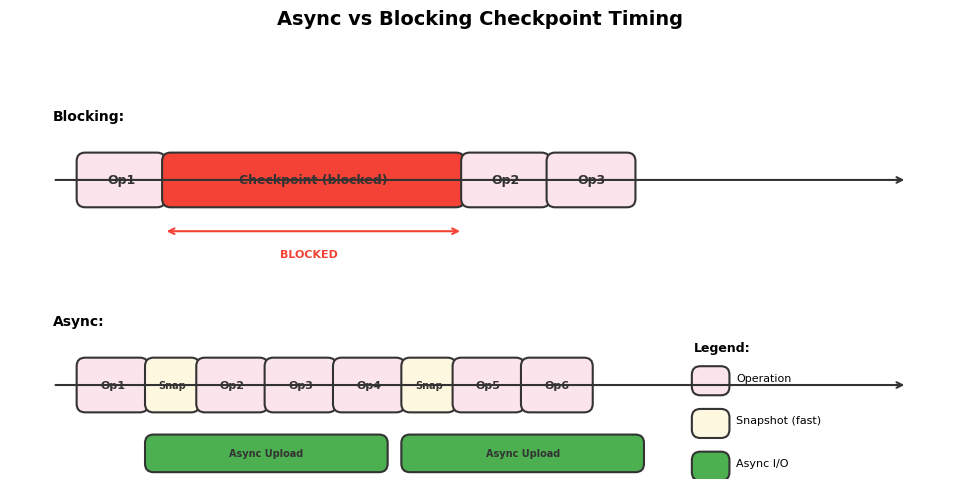

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
setup_ax(fig, ax, 'Async vs Blocking Checkpoint Timing')

# Blocking timeline
ax.text(0.5, 4.2, 'Blocking:', fontsize=10, fontweight='bold')

# Timeline arrow
draw_arrow(ax, 0.5, 3.5, 10.5, 3.5)

# Blocking segments
draw_box(ax, 0.8, 3.2, 1, 0.6, 'Op1', color=COLORS['impl'], fontsize=9)
draw_box(ax, 1.8, 3.2, 3.5, 0.6, 'Checkpoint (blocked)', color=COLORS['danger'], fontsize=9)
draw_box(ax, 5.3, 3.2, 1, 0.6, 'Op2', color=COLORS['impl'], fontsize=9)
draw_box(ax, 6.3, 3.2, 1, 0.6, 'Op3', color=COLORS['impl'], fontsize=9)

# Blocked annotation
ax.annotate('', xy=(5.3, 2.9), xytext=(1.8, 2.9),
           arrowprops=dict(arrowstyle='<->', color=COLORS['danger'], lw=1.5))
ax.text(3.5, 2.6, 'BLOCKED', fontsize=8, ha='center', color=COLORS['danger'], fontweight='bold')

# Async timeline
ax.text(0.5, 1.8, 'Async:', fontsize=10, fontweight='bold')

# Timeline arrow
draw_arrow(ax, 0.5, 1.1, 10.5, 1.1)

# Async segments - operations
draw_box(ax, 0.8, 0.8, 0.8, 0.6, 'Op1', color=COLORS['impl'], fontsize=8)
draw_box(ax, 1.6, 0.8, 0.6, 0.6, 'Snap', color=COLORS['coord'], fontsize=7)
draw_box(ax, 2.2, 0.8, 0.8, 0.6, 'Op2', color=COLORS['impl'], fontsize=8)
draw_box(ax, 3.0, 0.8, 0.8, 0.6, 'Op3', color=COLORS['impl'], fontsize=8)
draw_box(ax, 3.8, 0.8, 0.8, 0.6, 'Op4', color=COLORS['impl'], fontsize=8)
draw_box(ax, 4.6, 0.8, 0.6, 0.6, 'Snap', color=COLORS['coord'], fontsize=7)
draw_box(ax, 5.2, 0.8, 0.8, 0.6, 'Op5', color=COLORS['impl'], fontsize=8)
draw_box(ax, 6.0, 0.8, 0.8, 0.6, 'Op6', color=COLORS['impl'], fontsize=8)

# Async upload bars (below timeline)
draw_box(ax, 1.6, 0.1, 2.8, 0.4, 'Async Upload', color=COLORS['safe'], fontsize=7)
draw_box(ax, 4.6, 0.1, 2.8, 0.4, 'Async Upload', color=COLORS['safe'], fontsize=7)

# Legend
ax.text(8, 1.5, 'Legend:', fontsize=9, fontweight='bold')
draw_box(ax, 8, 1.0, 0.4, 0.3, '', color=COLORS['impl'])
ax.text(8.5, 1.15, 'Operation', fontsize=8)
draw_box(ax, 8, 0.5, 0.4, 0.3, '', color=COLORS['coord'])
ax.text(8.5, 0.65, 'Snapshot (fast)', fontsize=8)
draw_box(ax, 8, 0.0, 0.4, 0.3, '', color=COLORS['safe'])
ax.text(8.5, 0.15, 'Async I/O', fontsize=8)

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/async_checkpoint_timing.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 5: Serverless Crash Problem

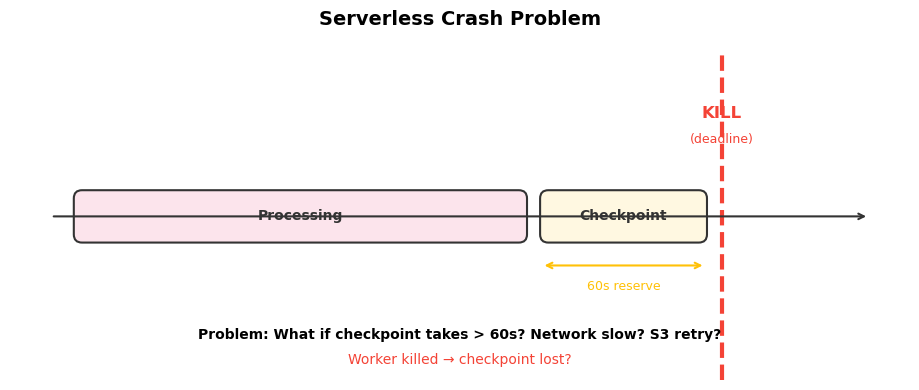

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
setup_ax(fig, ax, 'Serverless Crash Problem')

# Timeline arrow
draw_arrow(ax, 0.5, 2, 10.5, 2)

# Processing phase
draw_box(ax, 0.8, 1.7, 5.5, 0.6, 'Processing', color=COLORS['impl'], fontsize=10)

# Checkpoint phase
draw_box(ax, 6.5, 1.7, 2, 0.6, 'Checkpoint', color=COLORS['coord'], fontsize=10)

# KILL marker
ax.axvline(x=8.7, color=COLORS['danger'], linewidth=3, linestyle='--')
ax.text(8.7, 3.2, 'KILL', fontsize=12, fontweight='bold', color=COLORS['danger'], ha='center')
ax.text(8.7, 2.9, '(deadline)', fontsize=9, color=COLORS['danger'], ha='center')

# Reserve time annotation
ax.annotate('', xy=(8.5, 1.4), xytext=(6.5, 1.4),
           arrowprops=dict(arrowstyle='<->', color=COLORS['warning'], lw=1.5))
ax.text(7.5, 1.1, '60s reserve', fontsize=9, ha='center', color=COLORS['warning'])

# Problem text
ax.text(5.5, 0.5, 'Problem: What if checkpoint takes > 60s? Network slow? S3 retry?',
        fontsize=10, ha='center', fontweight='bold')
ax.text(5.5, 0.2, 'Worker killed → checkpoint lost?', fontsize=10, ha='center', color=COLORS['danger'])

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/serverless_crash_problem.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 6: Checkpoint State Diagram

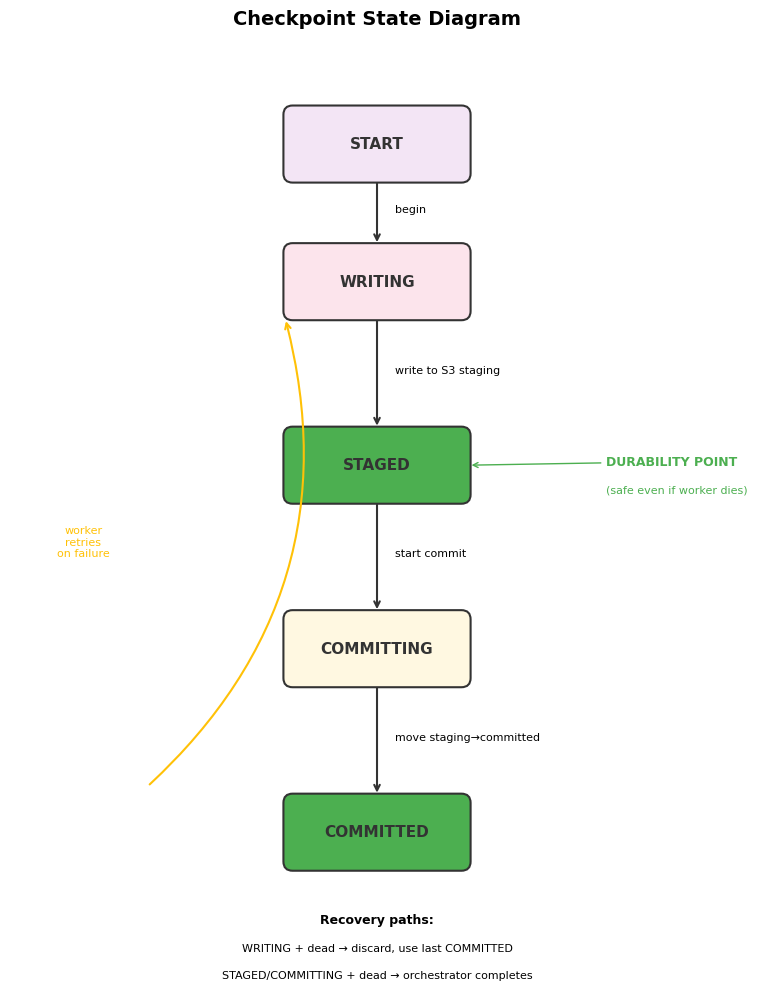

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
ax.set_xlim(0, 8)
ax.set_ylim(0, 10)
setup_ax(fig, ax, 'Checkpoint State Diagram')

# States
states = [
    (4, 9, 'START', COLORS['shared']),
    (4, 7.5, 'WRITING', COLORS['impl']),
    (4, 5.5, 'STAGED', COLORS['safe']),
    (4, 3.5, 'COMMITTING', COLORS['coord']),
    (4, 1.5, 'COMMITTED', COLORS['safe']),
]

for x, y, label, color in states:
    draw_box(ax, x - 1, y - 0.4, 2, 0.8, label, color=color, fontsize=11)

# Arrows between states
draw_arrow(ax, 4, 8.6, 4, 7.9)
draw_arrow(ax, 4, 7.1, 4, 5.9)
draw_arrow(ax, 4, 5.1, 4, 3.9)
draw_arrow(ax, 4, 3.1, 4, 1.9)

# Labels on arrows
ax.text(4.2, 8.25, 'begin', fontsize=8)
ax.text(4.2, 6.5, 'write to S3 staging', fontsize=8)
ax.text(4.2, 4.5, 'start commit', fontsize=8)
ax.text(4.2, 2.5, 'move staging→committed', fontsize=8)

# Durability point annotation
ax.annotate('DURABILITY POINT', xy=(5, 5.5), xytext=(6.5, 5.5),
           fontsize=9, fontweight='bold', color=COLORS['safe'],
           arrowprops=dict(arrowstyle='->', color=COLORS['safe']))
ax.text(6.5, 5.2, '(safe even if worker dies)', fontsize=8, color=COLORS['safe'])

# Recovery arrow
ax.annotate('', xy=(3, 7.1), xytext=(1.5, 2),
           arrowprops=dict(arrowstyle='->', color=COLORS['warning'],
                          connectionstyle='arc3,rad=0.3', lw=1.5))
ax.text(0.8, 4.5, 'worker\nretries\non failure', fontsize=8, ha='center', color=COLORS['warning'])

# Recovery paths note
ax.text(4, 0.5, 'Recovery paths:', fontsize=9, fontweight='bold', ha='center')
ax.text(4, 0.2, 'WRITING + dead → discard, use last COMMITTED', fontsize=8, ha='center')
ax.text(4, -0.1, 'STAGED/COMMITTING + dead → orchestrator completes', fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/checkpoint_state_diagram.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 7: AWS ParallelCluster Architecture

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
setup_ax(fig, ax, 'AWS ParallelCluster Architecture')

# Main container
draw_box(ax, 0.5, 0.5, 10, 7, '', color='#E3F2FD')
ax.text(5.5, 7.2, 'AWS ParallelCluster', fontsize=12, fontweight='bold', ha='center')

# Compute nodes
for i in range(4):
    x = 1.5 + i * 2.2
    draw_box(ax, x, 5.5, 1.8, 1, '', color=COLORS['impl'])
    ax.text(x + 0.9, 6.3, f'c6i.8xl', fontsize=8, ha='center', fontweight='bold')
    ax.text(x + 0.9, 5.9, '+ EFA', fontsize=8, ha='center')

# EFA Network
draw_box(ax, 1.5, 3.5, 8, 1.2, '', color=COLORS['coord'])
ax.text(5.5, 4.3, 'EFA Network (libfabric)', fontsize=10, ha='center', fontweight='bold')
ax.text(5.5, 3.8, 'Low-latency MPI communication (OS-bypass)', fontsize=9, ha='center')

# Arrows from nodes to EFA
for i in range(4):
    x = 2.4 + i * 2.2
    draw_arrow(ax, x, 5.5, x, 4.7)

# FSx for Lustre
draw_box(ax, 1.5, 1, 8, 1.8, '', color=COLORS['storage'])
ax.text(5.5, 2.5, 'FSx for Lustre', fontsize=10, ha='center', fontweight='bold')
ax.text(5.5, 2.1, '• High throughput parallel writes', fontsize=9, ha='center')
ax.text(5.5, 1.7, '• S3 integration for data staging', fontsize=9, ha='center')
ax.text(5.5, 1.3, '• /fsx mount point', fontsize=9, ha='center')

# Arrow from EFA to Lustre
draw_arrow(ax, 5.5, 3.5, 5.5, 2.8)

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/aws_parallelcluster.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 8: Serverless Architecture

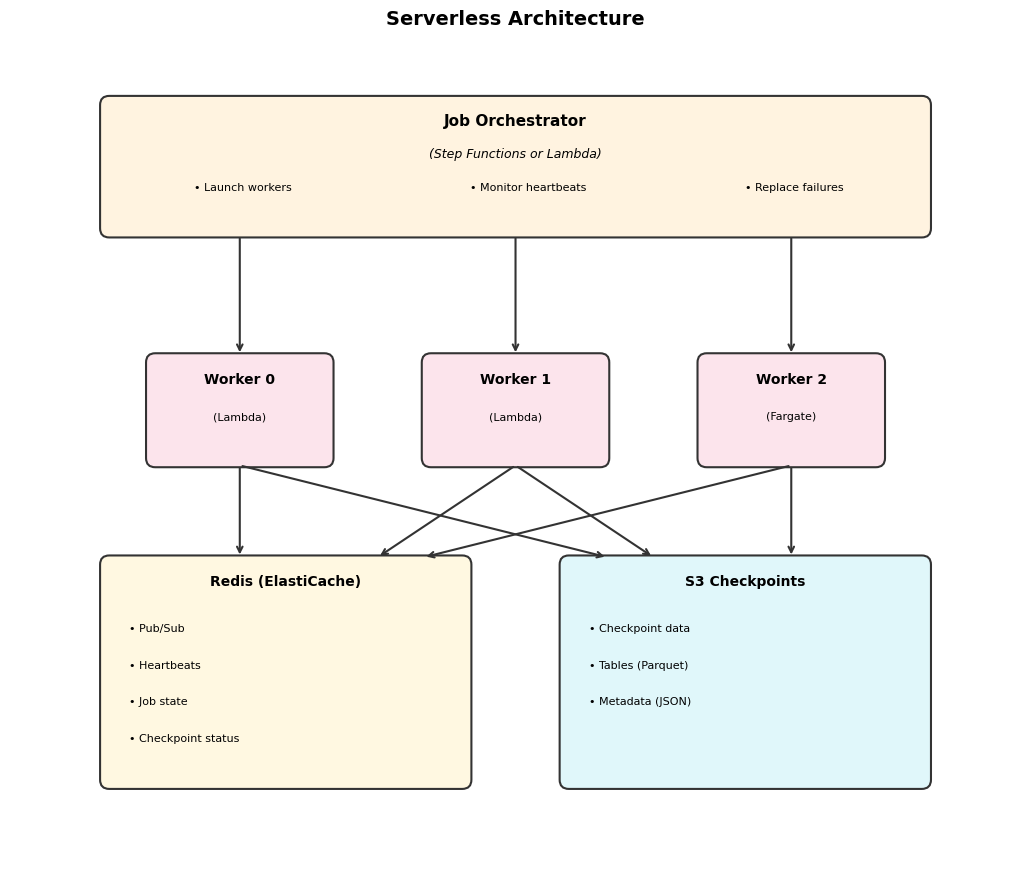

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(11, 9))
ax.set_xlim(0, 11)
ax.set_ylim(0, 9)
setup_ax(fig, ax, 'Serverless Architecture')

# Job Orchestrator
draw_box(ax, 1, 7, 9, 1.5, '', color=COLORS['manager'])
ax.text(5.5, 8.2, 'Job Orchestrator', fontsize=11, fontweight='bold', ha='center')
ax.text(5.5, 7.85, '(Step Functions or Lambda)', fontsize=9, ha='center', style='italic')
ax.text(2, 7.5, '• Launch workers', fontsize=8)
ax.text(5, 7.5, '• Monitor heartbeats', fontsize=8)
ax.text(8, 7.5, '• Replace failures', fontsize=8)

# Workers
workers = [
    (1.5, 'Worker 0', 'Lambda'),
    (4.5, 'Worker 1', 'Lambda'),
    (7.5, 'Worker 2', 'Fargate'),
]

for x, label, runtime in workers:
    draw_box(ax, x, 4.5, 2, 1.2, '', color=COLORS['impl'])
    ax.text(x + 1, 5.4, label, fontsize=10, ha='center', fontweight='bold')
    ax.text(x + 1, 5.0, f'({runtime})', fontsize=8, ha='center')

# Arrows from orchestrator to workers
for x in [2.5, 5.5, 8.5]:
    draw_arrow(ax, x, 7, x, 5.7)

# Storage layer
# Redis
draw_box(ax, 1, 1, 4, 2.5, '', color=COLORS['coord'])
ax.text(3, 3.2, 'Redis (ElastiCache)', fontsize=10, ha='center', fontweight='bold')
ax.text(1.3, 2.7, '• Pub/Sub', fontsize=8)
ax.text(1.3, 2.3, '• Heartbeats', fontsize=8)
ax.text(1.3, 1.9, '• Job state', fontsize=8)
ax.text(1.3, 1.5, '• Checkpoint status', fontsize=8)

# S3
draw_box(ax, 6, 1, 4, 2.5, '', color=COLORS['storage'])
ax.text(8, 3.2, 'S3 Checkpoints', fontsize=10, ha='center', fontweight='bold')
ax.text(6.3, 2.7, '• Checkpoint data', fontsize=8)
ax.text(6.3, 2.3, '• Tables (Parquet)', fontsize=8)
ax.text(6.3, 1.9, '• Metadata (JSON)', fontsize=8)

# All workers connect to both Redis and S3
# Worker 0 -> Redis and S3
draw_arrow(ax, 2.5, 4.5, 2.5, 3.5)   # to Redis
draw_arrow(ax, 2.5, 4.5, 6.5, 3.5)   # to S3

# Worker 1 -> Redis and S3
draw_arrow(ax, 5.5, 4.5, 4, 3.5)     # to Redis
draw_arrow(ax, 5.5, 4.5, 7, 3.5)     # to S3

# Worker 2 -> Redis and S3
draw_arrow(ax, 8.5, 4.5, 4.5, 3.5)   # to Redis
draw_arrow(ax, 8.5, 4.5, 8.5, 3.5)   # to S3

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/serverless_architecture.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 9: Lambda vs Fargate

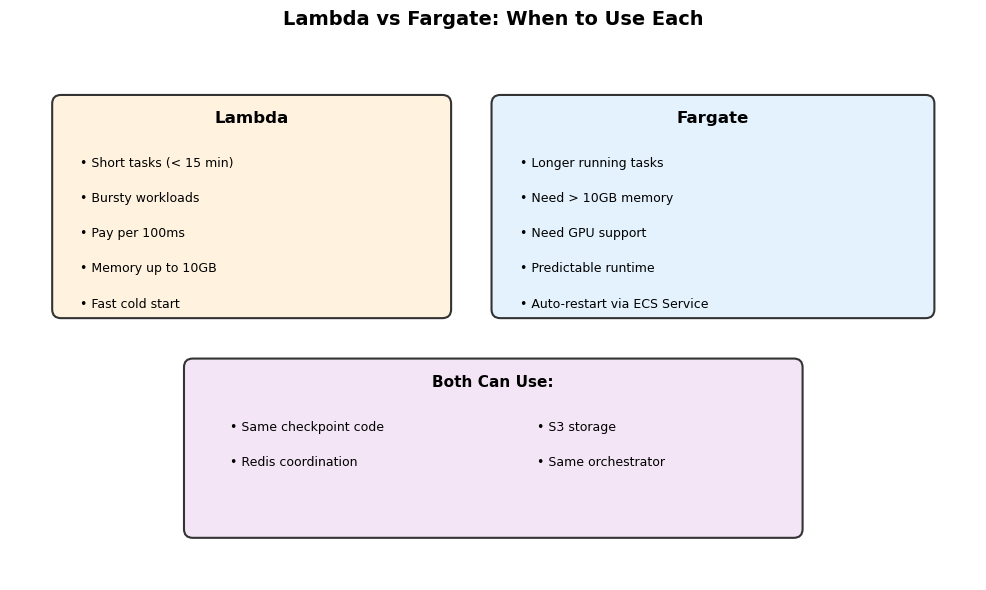

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
setup_ax(fig, ax, 'Lambda vs Fargate: When to Use Each')

# Lambda box
draw_box(ax, 0.5, 3, 4.5, 2.5, '', color='#FFF3E0')
ax.text(2.75, 5.2, 'Lambda', fontsize=12, fontweight='bold', ha='center')
ax.text(0.8, 4.7, '• Short tasks (< 15 min)', fontsize=9)
ax.text(0.8, 4.3, '• Bursty workloads', fontsize=9)
ax.text(0.8, 3.9, '• Pay per 100ms', fontsize=9)
ax.text(0.8, 3.5, '• Memory up to 10GB', fontsize=9)
ax.text(0.8, 3.1, '• Fast cold start', fontsize=9)

# Fargate box
draw_box(ax, 5.5, 3, 5, 2.5, '', color='#E3F2FD')
ax.text(8, 5.2, 'Fargate', fontsize=12, fontweight='bold', ha='center')
ax.text(5.8, 4.7, '• Longer running tasks', fontsize=9)
ax.text(5.8, 4.3, '• Need > 10GB memory', fontsize=9)
ax.text(5.8, 3.9, '• Need GPU support', fontsize=9)
ax.text(5.8, 3.5, '• Predictable runtime', fontsize=9)
ax.text(5.8, 3.1, '• Auto-restart via ECS Service', fontsize=9)

# Shared box
draw_box(ax, 2, 0.5, 7, 2, '', color=COLORS['shared'])
ax.text(5.5, 2.2, 'Both Can Use:', fontsize=11, fontweight='bold', ha='center')
ax.text(2.5, 1.7, '• Same checkpoint code', fontsize=9)
ax.text(2.5, 1.3, '• Redis coordination', fontsize=9)
ax.text(6, 1.7, '• S3 storage', fontsize=9)
ax.text(6, 1.3, '• Same orchestrator', fontsize=9)

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/lambda_vs_fargate.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 10: Step Functions State Machine

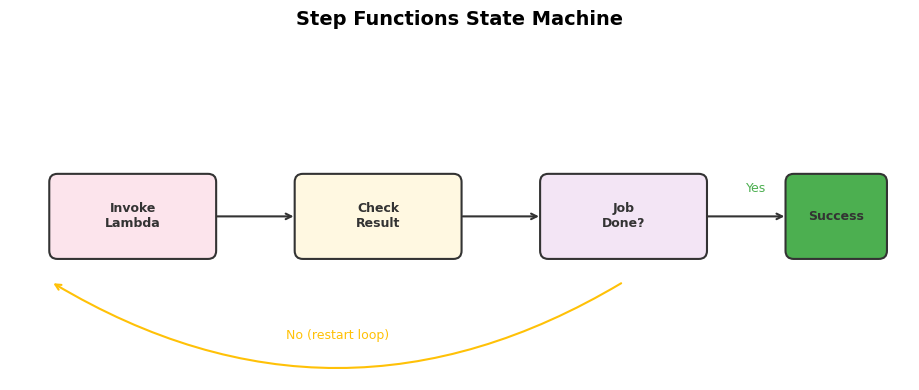

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
setup_ax(fig, ax, 'Step Functions State Machine')

# States
draw_box(ax, 0.5, 1.5, 2, 1, 'Invoke\nLambda', color=COLORS['impl'], fontsize=9)
draw_box(ax, 3.5, 1.5, 2, 1, 'Check\nResult', color=COLORS['coord'], fontsize=9)
draw_box(ax, 6.5, 1.5, 2, 1, 'Job\nDone?', color=COLORS['shared'], fontsize=9)
draw_box(ax, 9.5, 1.5, 1.2, 1, 'Success', color=COLORS['safe'], fontsize=9)

# Arrows
draw_arrow(ax, 2.5, 2, 3.5, 2)
draw_arrow(ax, 5.5, 2, 6.5, 2)
draw_arrow(ax, 8.5, 2, 9.5, 2)

# Loop back arrow (No path)
ax.annotate('', xy=(0.5, 1.2), xytext=(7.5, 1.2),
           arrowprops=dict(arrowstyle='->', color=COLORS['warning'],
                          connectionstyle='arc3,rad=-0.3', lw=1.5))
ax.text(4, 0.5, 'No (restart loop)', fontsize=9, ha='center', color=COLORS['warning'])

# Yes label
ax.text(9, 2.3, 'Yes', fontsize=9, color=COLORS['safe'])

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/step_functions.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 11: Checkpoint Timeline

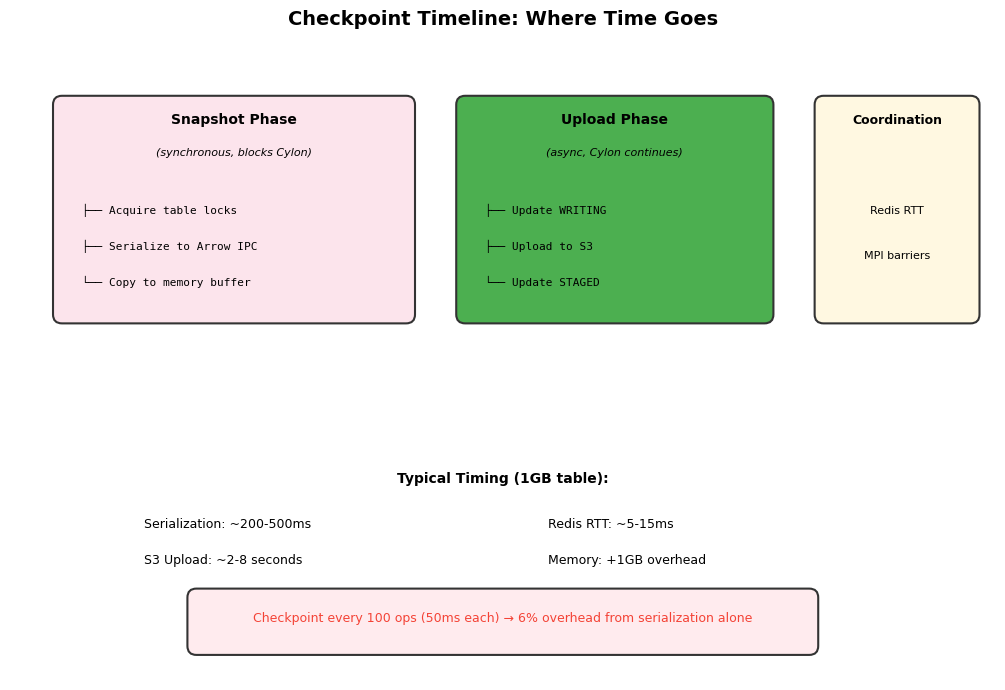

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(11, 7))
ax.set_xlim(0, 11)
ax.set_ylim(0, 7)
setup_ax(fig, ax, 'Checkpoint Timeline: Where Time Goes')

# Main timeline structure - boxes with labels inside
y_start = 4.5

# Snapshot Phase - make box taller to fit header inside
draw_box(ax, 0.5, y_start - 0.5, 4, 2.5, '', color=COLORS['impl'])
ax.text(2.5, y_start + 1.7, 'Snapshot Phase', fontsize=10, fontweight='bold', ha='center')
ax.text(2.5, y_start + 1.35, '(synchronous, blocks Cylon)', fontsize=8, ha='center', style='italic')
ax.text(0.8, y_start + 0.7, '├── Acquire table locks', fontsize=8, family='monospace')
ax.text(0.8, y_start + 0.3, '├── Serialize to Arrow IPC', fontsize=8, family='monospace')
ax.text(0.8, y_start - 0.1, '└── Copy to memory buffer', fontsize=8, family='monospace')

# Upload Phase
draw_box(ax, 5, y_start - 0.5, 3.5, 2.5, '', color=COLORS['safe'])
ax.text(6.75, y_start + 1.7, 'Upload Phase', fontsize=10, fontweight='bold', ha='center')
ax.text(6.75, y_start + 1.35, '(async, Cylon continues)', fontsize=8, ha='center', style='italic')
ax.text(5.3, y_start + 0.7, '├── Update WRITING', fontsize=8, family='monospace')
ax.text(5.3, y_start + 0.3, '├── Upload to S3', fontsize=8, family='monospace')
ax.text(5.3, y_start - 0.1, '└── Update STAGED', fontsize=8, family='monospace')

# Coordination
draw_box(ax, 9, y_start - 0.5, 1.8, 2.5, '', color=COLORS['coord'])
ax.text(9.9, y_start + 1.7, 'Coordination', fontsize=9, fontweight='bold', ha='center')
ax.text(9.9, y_start + 0.7, 'Redis RTT', fontsize=8, ha='center')
ax.text(9.9, y_start + 0.2, 'MPI barriers', fontsize=8, ha='center')

# Timing estimates
ax.text(5.5, 2.2, 'Typical Timing (1GB table):', fontsize=10, fontweight='bold', ha='center')
ax.text(1.5, 1.7, 'Serialization: ~200-500ms', fontsize=9)
ax.text(1.5, 1.3, 'S3 Upload: ~2-8 seconds', fontsize=9)
ax.text(6, 1.7, 'Redis RTT: ~5-15ms', fontsize=9)
ax.text(6, 1.3, 'Memory: +1GB overhead', fontsize=9)

# Impact note
draw_box(ax, 2, 0.3, 7, 0.7, '', color='#FFEBEE')
ax.text(5.5, 0.65, 'Checkpoint every 100 ops (50ms each) → 6% overhead from serialization alone',
        fontsize=9, ha='center', color=COLORS['danger'])

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/checkpoint_timeline.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Diagram 12: Storage Directory Structure

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))

# MPI Storage Structure
ax1.set_xlim(0, 5)
ax1.set_ylim(0, 8)
setup_ax(fig, ax1, 'MPI/HPC Storage (Lustre)')

structure_mpi = """
/fsx/checkpoints/job_123/
├── metadata/
│   ├── checkpoint_000001.json
│   ├── checkpoint_000002.json
│   └── latest.json
├── staging/
│   └── checkpoint_000003/
│       ├── rank_0/
│       │   └── table.arrow
│       └── rank_1/
│           └── table.arrow
└── committed/
    ├── checkpoint_000001/
    │   └── ...
    └── checkpoint_000002/
        └── ...
"""
ax1.text(0.1, 7.5, structure_mpi, fontsize=8, family='monospace', va='top')

# Serverless Storage Structure
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 8)
setup_ax(fig, ax2, 'Serverless Storage (S3)')

structure_s3 = """
s3://bucket/checkpoints/job_123/
├── metadata/
│   ├── checkpoint_000001.json
│   └── checkpoint_000002.json
├── staging/
│   └── checkpoint_000003/
│       ├── worker_abc123/
│       │   └── table.parquet
│       └── worker_def456/
│           └── table.parquet
└── committed/
    ├── checkpoint_000001/
    │   └── ...
    └── checkpoint_000002/
        └── ...
"""
ax2.text(0.1, 7.5, structure_s3, fontsize=8, family='monospace', va='top')

plt.tight_layout()
plt.savefig('/home/parallels/cylon/rust/docs/storage_structure.png',
            dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

## Generate All Diagrams

Run all cells above to regenerate all diagrams, or run the cell below to regenerate them all at once.

In [ ]:
print("All diagrams generated!")
print("Location: /home/parallels/cylon/rust/docs/")